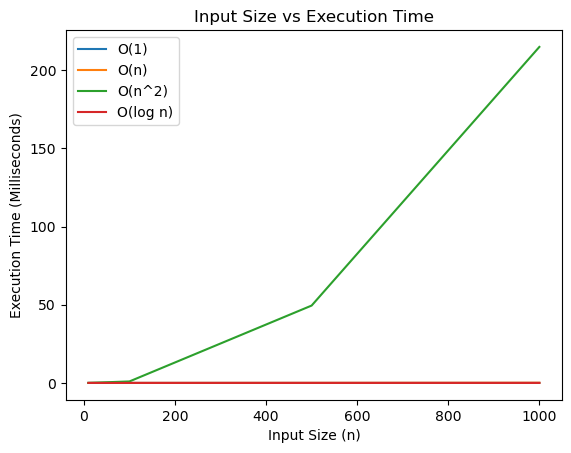

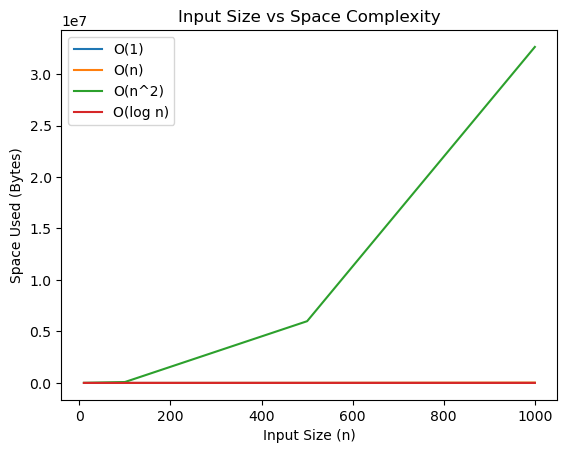

In [1]:
# TASK 1: Algorithm Growth Observation

import time
import math
import matplotlib.pyplot as plt
import tracemalloc

def constant_time(n):
    return n * 10

def linear_time(n):
    total = 0
    arr = []
    for i in range(n):
        total += i
        arr.append(i)
    return total

def quadratic_time(n):
    total = 0
    arr = []
    for i in range(n):
        temp = []
        for j in range(n):
            total += i + j
            temp.append(j)
        arr.append(temp)
    return total

def logarithmic_time(n):
    count = 0
    arr = []
    while n > 1:
        n = n // 2
        count += 1
        arr.append(count)
    return count

def measure_time(func, n):
    start = time.time()
    func(n)
    end = time.time()
    return (end - start) * 1000

def measure_space(func, n):
    tracemalloc.start()
    func(n)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak

input_sizes = [10, 100, 500, 1000]

constant_times = []
linear_times = []
quadratic_times = []
log_times = []

constant_space = []
linear_space = []
quadratic_space = []
log_space = []

for n in input_sizes:
    constant_times.append(measure_time(constant_time, n))
    linear_times.append(measure_time(linear_time, n))
    quadratic_times.append(measure_time(quadratic_time, n))
    log_times.append(measure_time(logarithmic_time, n))

    constant_space.append(measure_space(constant_time, n))
    linear_space.append(measure_space(linear_time, n))
    quadratic_space.append(measure_space(quadratic_time, n))
    log_space.append(measure_space(logarithmic_time, n))

plt.figure()
plt.plot(input_sizes, constant_times)
plt.plot(input_sizes, linear_times)
plt.plot(input_sizes, quadratic_times)
plt.plot(input_sizes, log_times)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (Milliseconds)")
plt.title("Input Size vs Execution Time")
plt.legend(["O(1)", "O(n)", "O(n^2)", "O(log n)"])
plt.show()

plt.figure()
plt.plot(input_sizes, constant_space)
plt.plot(input_sizes, linear_space)
plt.plot(input_sizes, quadratic_space)
plt.plot(input_sizes, log_space)
plt.xlabel("Input Size (n)")
plt.ylabel("Space Used (Bytes)")
plt.title("Input Size vs Space Complexity")
plt.legend(["O(1)", "O(n)", "O(n^2)", "O(log n)"])
plt.show()


Input Size: 100
Linear (ms) - B: 0.0043, A: 0.0033, W: 0.0060
Binary (ms) - B: 0.0033, A: 0.0017, W: 0.0014
Space (Bytes) - Lin: 80, Bin: 0
----------------------------------
Input Size: 1000
Linear (ms) - B: 0.0041, A: 0.0203, W: 0.0432
Binary (ms) - B: 0.0029, A: 0.0026, W: 0.0019
Space (Bytes) - Lin: 140, Bin: 160
----------------------------------
Input Size: 5000
Linear (ms) - B: 0.0031, A: 0.0727, W: 0.2055
Binary (ms) - B: 0.0024, A: 0.0017, W: 0.0026
Space (Bytes) - Lin: 140, Bin: 160
----------------------------------
Input Size: 10000
Linear (ms) - B: 0.0050, A: 0.3867, W: 0.5558
Binary (ms) - B: 0.0038, A: 0.0050, W: 0.0069
Space (Bytes) - Lin: 140, Bin: 160
----------------------------------


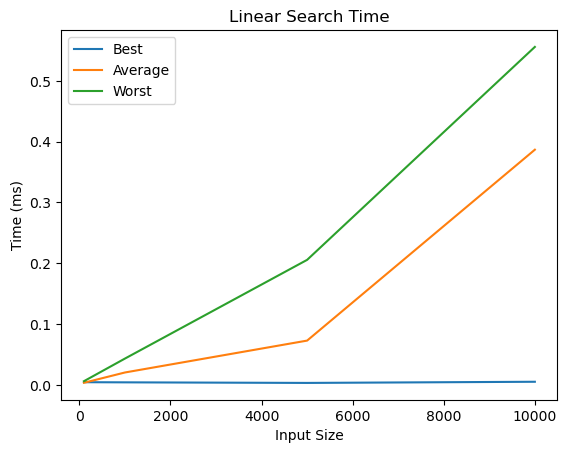

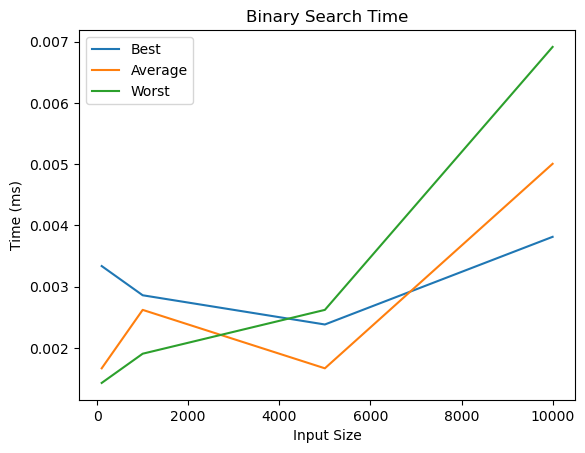

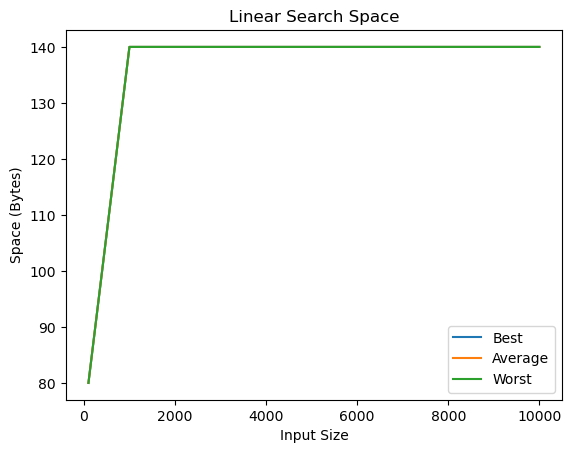

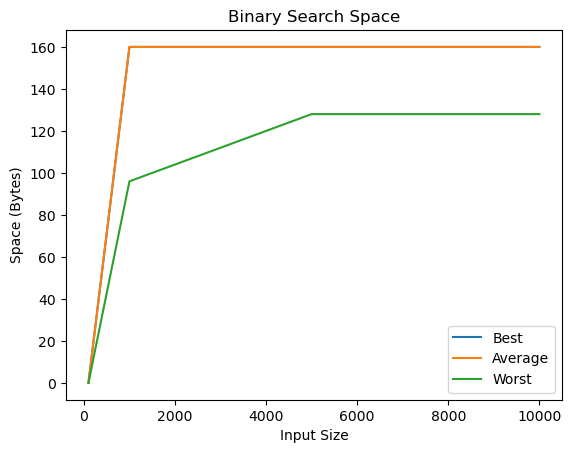

In [2]:
# TASK 2: Best, Average, Worst Case Analysis

import time
import random
import matplotlib.pyplot as plt
import tracemalloc

def linear_search(arr, key):
    for i in range(len(arr)):
        if arr[i] == key:
            return i
    return -1

def binary_search(arr, key):
    low = 0
    high = len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == key:
            return mid
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1
    return -1

def measure_time(func, arr, key):
    start = time.time()
    func(arr, key)
    end = time.time()
    return (end - start) * 1000

def measure_space(func, arr, key):
    tracemalloc.start()
    func(arr, key)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak

sizes = [100, 1000, 5000, 10000]

linear_best, linear_avg, linear_worst = [], [], []
binary_best, binary_avg, binary_worst = [], [], []
linear_best_space, linear_avg_space, linear_worst_space = [], [], []
binary_best_space, binary_avg_space, binary_worst_space = [], [], []

for n in sizes:
    arr = sorted(random.sample(range(n*2), n))
    
    lb = measure_time(linear_search, arr, arr[0])
    bb = measure_time(binary_search, arr, arr[n//2])
    lbs = measure_space(linear_search, arr, arr[0])
    bbs = measure_space(binary_search, arr, arr[n//2])
    
    la = measure_time(linear_search, arr, arr[n//2])
    ba = measure_time(binary_search, arr, arr[random.randint(0, n-1)])
    las = measure_space(linear_search, arr, arr[n//2])
    bas = measure_space(binary_search, arr, arr[random.randint(0, n-1)])
    
    lw = measure_time(linear_search, arr, -1)
    bw = measure_time(binary_search, arr, -1)
    lws = measure_space(linear_search, arr, -1)
    bws = measure_space(binary_search, arr, -1)
    
    linear_best.append(lb); linear_avg.append(la); linear_worst.append(lw)
    binary_best.append(bb); binary_avg.append(ba); binary_worst.append(bw)
    linear_best_space.append(lbs); linear_avg_space.append(las); linear_worst_space.append(lws)
    binary_best_space.append(bbs); binary_avg_space.append(bas); binary_worst_space.append(bws)
    
    print(f"Input Size: {n}")
    print(f"Linear (ms) - B: {lb:.4f}, A: {la:.4f}, W: {lw:.4f}")
    print(f"Binary (ms) - B: {bb:.4f}, A: {ba:.4f}, W: {bw:.4f}")
    print(f"Space (Bytes) - Lin: {lbs}, Bin: {bbs}")
    print("-" * 34)

plt.figure()
plt.plot(sizes, linear_best, label="Best")
plt.plot(sizes, linear_avg, label="Average")
plt.plot(sizes, linear_worst, label="Worst")
plt.xlabel("Input Size"); plt.ylabel("Time (ms)"); plt.title("Linear Search Time"); plt.legend(); plt.show()

plt.figure()
plt.plot(sizes, binary_best, label="Best")
plt.plot(sizes, binary_avg, label="Average")
plt.plot(sizes, binary_worst, label="Worst")
plt.xlabel("Input Size"); plt.ylabel("Time (ms)"); plt.title("Binary Search Time"); plt.legend(); plt.show()

plt.figure()
plt.plot(sizes, linear_best_space, label="Best")
plt.plot(sizes, linear_avg_space, label="Average")
plt.plot(sizes, linear_worst_space, label="Worst")
plt.xlabel("Input Size"); plt.ylabel("Space (Bytes)"); plt.title("Linear Search Space"); plt.legend(); plt.show()

plt.figure()
plt.plot(sizes, binary_best_space, label="Best")
plt.plot(sizes, binary_avg_space, label="Average")
plt.plot(sizes, binary_worst_space, label="Worst")
plt.xlabel("Input Size"); plt.ylabel("Space (Bytes)"); plt.title("Binary Search Space"); plt.legend(); plt.show()



Comparison Table
--------------------------------------------------------------
n | Fact Calls | Fact Time(ms) | FibN Calls | FibN Time(ms) | FibDP Time(ms)
--------------------------------------------------------------
5 | 12 | 0.004700 | 30 | 0.002900 | 0.004400
10 | 22 | 0.001700 | 354 | 0.019900 | 0.005900
20 | 42 | 0.019000 | 43782 | 6.580000 | 0.009000
25 | 52 | 0.005500 | 485570 | 43.753200 | 0.006900


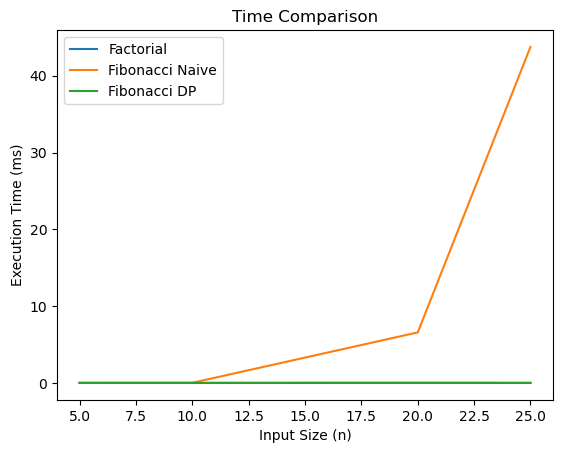

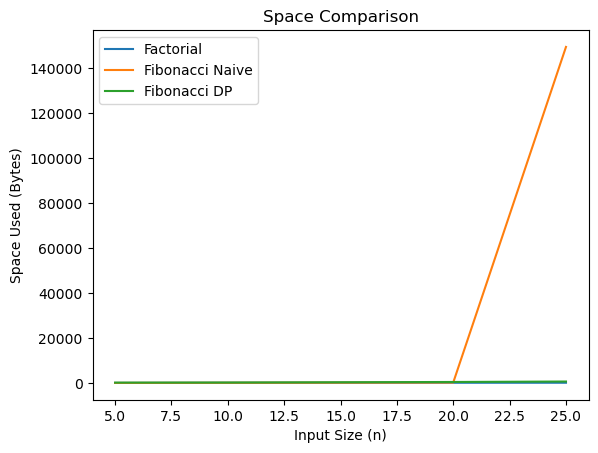

In [3]:
# Factorial vs Fibonacci Comparison

import time
import tracemalloc
import matplotlib.pyplot as plt

factorial_calls = 0

def factorial(n):
    global factorial_calls
    factorial_calls += 1
    if n == 0:
        return 1
    return n * factorial(n-1)

fib_naive_calls = 0

def fibonacci_naive(n):
    global fib_naive_calls
    fib_naive_calls += 1
    if n <= 1:
        return n
    return fibonacci_naive(n-1) + fibonacci_naive(n-2)

def fibonacci_dp(n):
    if n == 0: return 0
    if n == 1: return 1
    dp = [0] * (n + 1)
    dp[1] = 1
    for i in range(2, n + 1):
        dp[i] = dp[i-1] + dp[i-2]
    return dp[n]

def measure_time(func, n):
    start = time.perf_counter()
    func(n)
    end = time.perf_counter()
    return (end - start) * 1000

def measure_space(func, n):
    tracemalloc.start()
    func(n)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak

inputs = [5, 10, 20, 25]

fact_time, fib_naive_time, fib_dp_time = [], [], []
fact_space, fib_naive_space, fib_dp_space = [], [], []

print("\nComparison Table")
print("-" * 62)
print("n | Fact Calls | Fact Time(ms) | FibN Calls | FibN Time(ms) | FibDP Time(ms)")
print("-" * 62)

for n in inputs:
    factorial_calls = 0
    ft = measure_time(factorial, n)
    fs = measure_space(factorial, n)
    
    fib_naive_calls = 0
    fnt = measure_time(fibonacci_naive, n)
    fns = measure_space(fibonacci_naive, n)
    
    fdt = measure_time(fibonacci_dp, n)
    fds = measure_space(fibonacci_dp, n)
    
    fact_time.append(ft)
    fib_naive_time.append(fnt)
    fib_dp_time.append(fdt)
    
    fact_space.append(fs)
    fib_naive_space.append(fns)
    fib_dp_space.append(fds)
    
    print(f"{n} | {factorial_calls} | {ft:.6f} | {fib_naive_calls} | {fnt:.6f} | {fdt:.6f}")

plt.figure()
plt.plot(inputs, fact_time, label="Factorial")
plt.plot(inputs, fib_naive_time, label="Fibonacci Naive")
plt.plot(inputs, fib_dp_time, label="Fibonacci DP")
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (ms)")
plt.title("Time Comparison")
plt.legend()
plt.show()

plt.figure()
plt.plot(inputs, fact_space, label="Factorial")
plt.plot(inputs, fib_naive_space, label="Fibonacci Naive")
plt.plot(inputs, fib_dp_space, label="Fibonacci DP")
plt.xlabel("Input Size (n)")
plt.ylabel("Space Used (Bytes)")
plt.title("Space Comparison")
plt.legend()
plt.show()


     n |  T1 Time(ms) |   T1 Calls |  T2 Time(ms) |   T2 Calls
-----------------------------------------------------------------
     4 |     0.017700 |          3 |     0.002500 |          3
     8 |     0.002200 |          4 |     0.001300 |          4
    16 |     0.001800 |          5 |     0.001400 |          5
    32 |     0.001700 |          6 |     0.001900 |          6
    64 |     0.001100 |          7 |     0.004700 |          7
   128 |     0.001300 |          8 |     0.003600 |          8
   256 |     0.002200 |          9 |     0.005200 |          9
   512 |     0.003000 |         10 |     0.006400 |         10
  1024 |     0.004200 |         11 |     0.007600 |         11
  2048 |     0.005200 |         12 |     0.009000 |         12
  4096 |     0.006100 |         13 |     0.010300 |         13


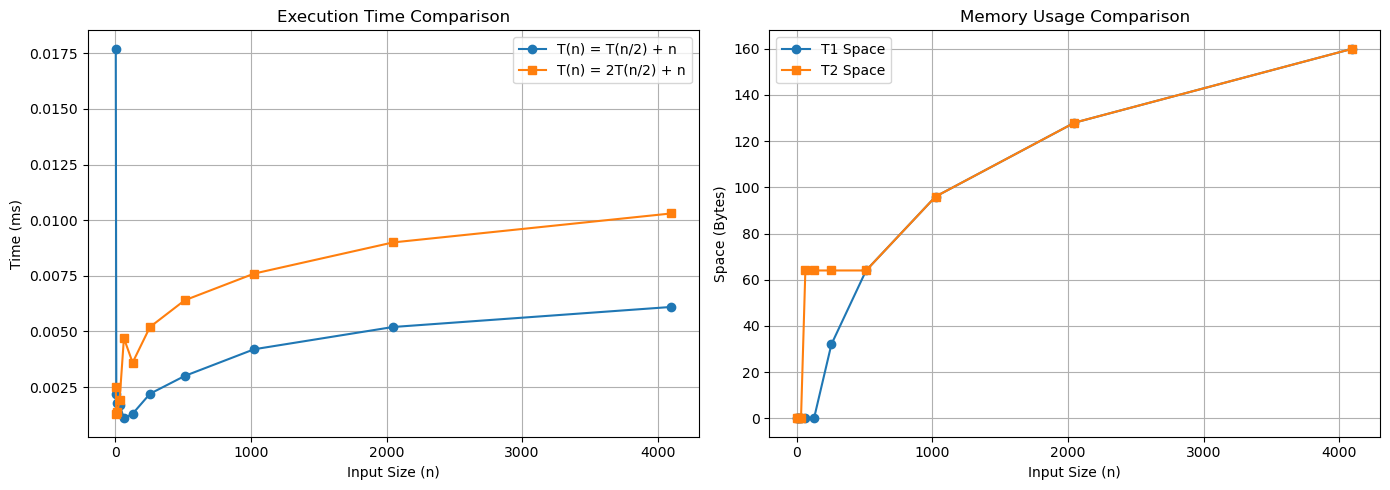

In [4]:
# TASK 4

import time
import sys
import tracemalloc
import matplotlib.pyplot as plt

calls_t1 = 0
calls_t2 = 0

def t1_recurrence(n):
    global calls_t1
    calls_t1 += 1
    if n <= 1:
        return 1
    return t1_recurrence(n // 2) + n

def t2_recurrence(n):
    global calls_t2
    calls_t2 += 1
    if n <= 1:
        return 1
    return 2 * t2_recurrence(n // 2) + n

def measure_metrics(func, n):
    global calls_t1, calls_t2
    calls_t1 = 0
    calls_t2 = 0
    
    tracemalloc.start()
    start = time.perf_counter()
    func(n)
    end = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    elapsed_ms = (end - start) * 1000
    calls = calls_t1 if func == t1_recurrence else calls_t2
    return elapsed_ms, peak, calls

sizes = [2**i for i in range(2, 13)] 
t1_times, t1_spaces, t1_calls = [], [], []
t2_times, t2_spaces, t2_calls = [], [], []

print(f"{'n':>6} | {'T1 Time(ms)':>12} | {'T1 Calls':>10} | {'T2 Time(ms)':>12} | {'T2 Calls':>10}")
print("-" * 65)

for n in sizes:
    tm1, sp1, cl1 = measure_metrics(t1_recurrence, n)
    tm2, sp2, cl2 = measure_metrics(t2_recurrence, n)
    
    t1_times.append(tm1); t1_spaces.append(sp1); t1_calls.append(cl1)
    t2_times.append(tm2); t2_spaces.append(sp2); t2_calls.append(cl2)
    
    print(f"{n:>6} | {tm1:>12.6f} | {cl1:>10} | {tm2:>12.6f} | {cl2:>10}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sizes, t1_times, label="T(n) = T(n/2) + n", marker='o')
ax1.plot(sizes, t2_times, label="T(n) = 2T(n/2) + n", marker='s')
ax1.set_title("Execution Time Comparison")
ax1.set_xlabel("Input Size (n)")
ax1.set_ylabel("Time (ms)")
ax1.legend(); ax1.grid(True)

ax2.plot(sizes, t1_spaces, label="T1 Space", marker='o')
ax2.plot(sizes, t2_spaces, label="T2 Space", marker='s')
ax2.set_title("Memory Usage Comparison")
ax2.set_xlabel("Input Size (n)")
ax2.set_ylabel("Space (Bytes)")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()
